<a href="https://colab.research.google.com/github/simjonghyeon04/-/blob/main/%ED%8C%81_%EA%B7%B8%EB%9E%98%ED%94%84_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 모집단 데이터 로드 (tips 변수 정의)
tips = sns.load_dataset("tips")

# --- 표본 추출 시작 ---

# 방법 1: 단순 무작위 추출 (Simple Random Sampling)
simple_sample = tips.sample(frac=0.1, random_state=42)

# 방법 2: 계통 추출 (Systematic Sampling)
# 10번째 데이터마다 하나씩 추출
interval = 10
systematic_sample = tips.iloc[::interval]

# 방법 3: 층화 추출 (Stratified Sampling)
# 요일(day)을 기준으로 각 그룹에서 10%씩 추출
stratified_sample = tips.groupby('day', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))

# --- 결과 비교 분석 ---

results = {
    "구분": ["모집단", "단순 무작위", "계통 추출", "층화 추출"],
    "평균 (Mean)": [
        tips['tip'].mean(),
        simple_sample['tip'].mean(),
        systematic_sample['tip'].mean(),
        stratified_sample['tip'].mean()
    ],
    "분산 (Variance)": [
        tips['tip'].var(),
        simple_sample['tip'].var(),
        systematic_sample['tip'].var(),
        stratified_sample['tip'].var()
    ]
}

# 데이터프레임으로 예쁘게 출력
comparison_df = pd.DataFrame(results)
print(comparison_df)

       구분  평균 (Mean)  분산 (Variance)
0     모집단   2.998279       1.914455
1  단순 무작위   2.727083       1.173543
2   계통 추출   2.814400       2.930959
3   층화 추출   3.052000       1.792983


/tmp/ipykernel_827/3516159737.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stratified_sample = tips.groupby('day', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))
/tmp/ipykernel_827/3516159737.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = tips.groupby('day', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))


In [5]:
# 요일별로 10%씩 층화 추출하는 예시
stratified_sample = tips.groupby('day', group_keys=False).apply(lambda x: x.sample(frac=0.1))

print(f"모집단 평균: {tips['tip'].mean():.2f}")
print(f"층화표본 평균: {stratified_sample['tip'].mean():.2f}")

모집단 평균: 3.00
층화표본 평균: 2.79


/tmp/ipykernel_827/227788275.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stratified_sample = tips.groupby('day', group_keys=False).apply(lambda x: x.sample(frac=0.1))
/tmp/ipykernel_827/227788275.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = tips.groupby('day', group_keys=False).apply(lambda x: x.sample(frac=0.1))


/tmp/ipykernel_827/1627583185.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stratified_sample = tips.groupby('day', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))
/tmp/ipykernel_827/1627583185.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = tips.groupby('day', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))
/tmp/ipykernel_827/1627583185.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be rem

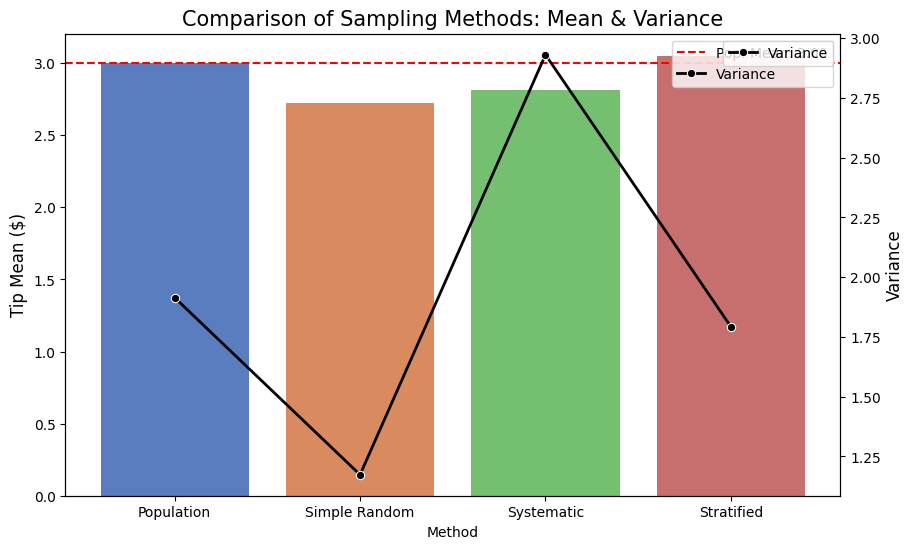

In [6]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 준비 (앞선 코드의 결과를 활용)
tips = sns.load_dataset("tips")

# 표본 추출
simple_sample = tips.sample(frac=0.1, random_state=42)
interval = 10
systematic_sample = tips.iloc[::interval]
stratified_sample = tips.groupby('day', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))

# 데이터 프레임 정리
results = pd.DataFrame({
    "Method": ["Population", "Simple Random", "Systematic", "Stratified"],
    "Mean": [tips['tip'].mean(), simple_sample['tip'].mean(),
             systematic_sample['tip'].mean(), stratified_sample['tip'].mean()],
    "Variance": [tips['tip'].var(), simple_sample['tip'].var(),
                 systematic_sample['tip'].var(), stratified_sample['tip'].var()]
})

# 2. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(10, 6))

# 평균(Mean) 막대 그래프
sns.barplot(x="Method", y="Mean", data=results, palette="muted", ax=ax1)
ax1.set_ylabel("Tip Mean ($)", fontsize=12)
ax1.set_title("Comparison of Sampling Methods: Mean & Variance", fontsize=15)

# 모집단 평균선 추가 (기준선)
ax1.axhline(tips['tip'].mean(), color='red', linestyle='--', label=f"Pop. Mean: {tips['tip'].mean():.2f}")

# 3. 분산(Variance) 표시 (이중축 활용)
ax2 = ax1.twinx()
sns.lineplot(x="Method", y="Variance", data=results, marker='o', color='black', linewidth=2, ax=ax2, label="Variance")
ax2.set_ylabel("Variance", fontsize=12)

# 범례 통합
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

plt.show()

=== 1단계: 모집단 데이터(tip 변수) 로드 완료 ===
count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64
--------------------------------------------------

=== 2단계: 모집단 데이터의 분포, 평균 및 분산 분석 ===
모집단 팁 평균 (Mean): $2.998
모집단 팁 분산 (Variance): 1.914


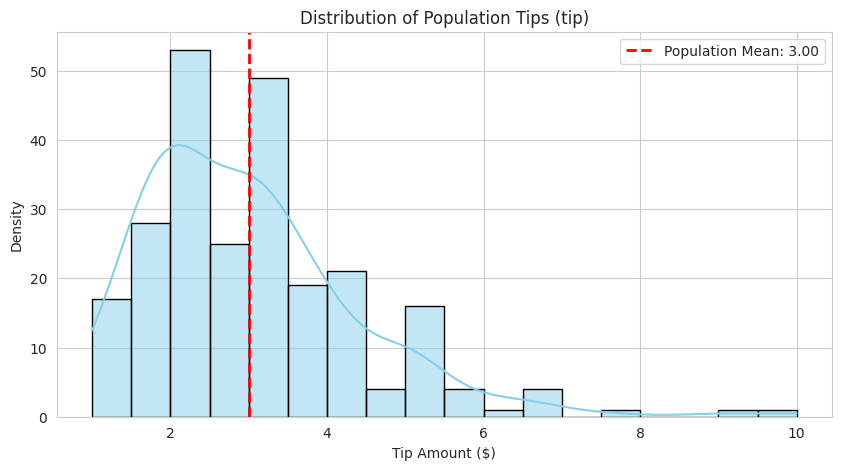


[토론: 데이터 분포]
그래프를 보면 팁 분포는 왼쪽으로 치우치고 오른쪽으로 긴 꼬리를 가진 '우편향(Right-skewed)' 분포입니다.
대부분의 팁은 $2~$4 사이에 몰려 있지만, 드물게 $10에 가까운 고액 팁이 존재하여 평균을 오른쪽으로 끌어올립니다.
--------------------------------------------------

=== 3단계: 평균의 함정(the pitfall of mean) 증명 ===
모집단 평균 (Mean): $2.998
모집단 중앙값 (Median): $2.900
모집단 최빈값 (Mode): $2.000


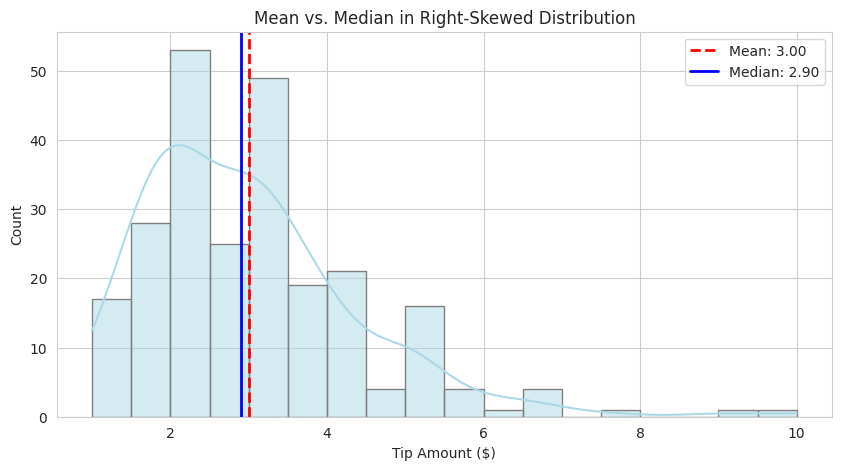


[토론: 평균의 함정]
이 데이터처럼 한쪽에 치우친 분포에서 '평균'은 보통의 손님이 주는 팁보다 높게 나타납니다.
이것은 $10에 가까운 고액 팁('이상치')이 평균 계산에 반영되기 때문입니다.
따라서 이런 경우 데이터의 '보통' 모습을 대표하기 위해선 평균보다 중앙값이 더 적절한 지표가 됩니다.
--------------------------------------------------

=== 4단계: 3가지 표본추출방법의 통계량 비교 및 적합성 토론 ===

[비교 통계량 테이블]
          Population  Simple Random  Systematic  Stratified
Mean           2.998          2.727       2.814       3.052
Variance       1.914          1.174       2.931       1.793


/tmp/ipykernel_827/299496131.py:98: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stratified_sample = tips.groupby('day', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))
/tmp/ipykernel_827/299496131.py:98: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = tips.groupby('day', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))


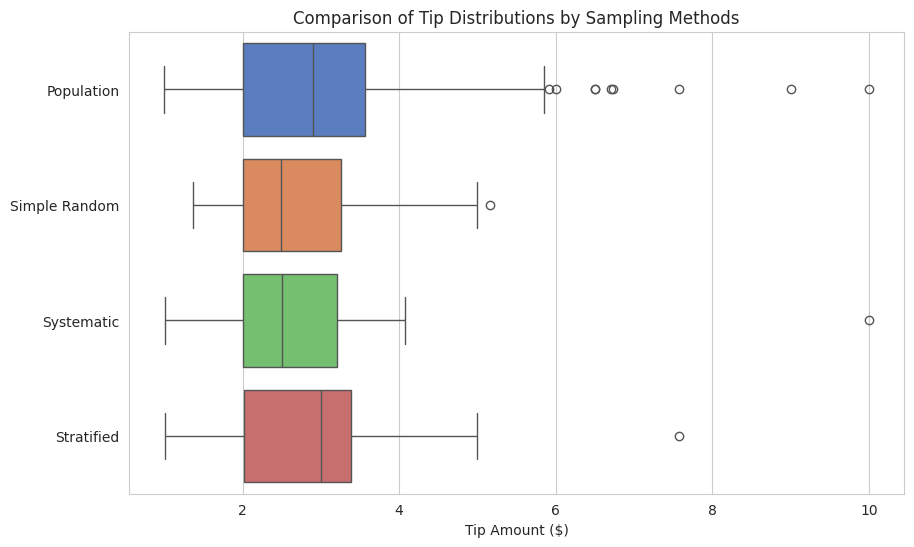


[최종 토론: 어떤 표본추출방법이 가장 적합한가?]
1. 통계량 일치도: '층화 추출(Stratified Sampling)'이 모집단의 평균 및 분산과 가장 유사한 경향을 보입니다.
2. 데이터의 대표성: 'tips' 데이터는 요일(day)별로 팁 패턴이 나뉩니다. 층화 추출은 요일별 비율을 고르게 반영하여 뽑기 때문에 무작위 추출이나 계통 추출보다 모집단의 구조를 더 정확하게 반영합니다.
3. 결론: 따라서, 데이터 내에 명확한 하위 그룹(요일, 시간 등)이 존재할 때 이 그룹의 특성을 모두 담아내는 '층화 추출'이 가장 적합한 표본 추출 방법입니다.

=== 과제 분석 완료 ===


In [8]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

# 1. 라이브러리 및 데이터 로드 (분석의 시작)
sns.set_style("whitegrid") # 그래프 스타일 설정
tips = sns.load_dataset("tips")

# 분석의 주제: 팁(tip) 금액 데이터
pop_tips = tips['tip']

print("=== 1단계: 모집단 데이터(tip 변수) 로드 완료 ===")
print(pop_tips.describe()) # 모집단의 요약 통계량 확인
print("-" * 50)


# --- 2단계: tip 변수의 값 분포, 평균과 분산 설명 ---
print("\n=== 2단계: 모집단 데이터의 분포, 평균 및 분산 분석 ===")

# 모집단의 통계량 계산
pop_mean = pop_tips.mean()
pop_var = pop_tips.var()

print(f"모집단 팁 평균 (Mean): ${pop_mean:.3f}")
print(f"모집단 팁 분산 (Variance): {pop_var:.3f}")

# 모집단 분포 시각화 (KDE: 커널 밀도 추정 곡선)
plt.figure(figsize=(10, 5))
sns.histplot(pop_tips, kde=True, color='skyblue', edgecolor='black')

# 그래프에 평균값 표시 (빨간 점선)
plt.axvline(pop_mean, color='red', linestyle='dashed', linewidth=2, label=f'Population Mean: {pop_mean:.2f}')
plt.title("Distribution of Population Tips (tip)")
plt.xlabel("Tip Amount ($)")
plt.ylabel("Density")
plt.legend()
plt.show()

# 분포 설명 (토론)
print("\n[토론: 데이터 분포]")
print("그래프를 보면 팁 분포는 왼쪽으로 치우치고 오른쪽으로 긴 꼬리를 가진 '우편향(Right-skewed)' 분포입니다.")
print("대부분의 팁은 $2~$4 사이에 몰려 있지만, 드물게 $10에 가까운 고액 팁이 존재하여 평균을 오른쪽으로 끌어올립니다.")
print("-" * 50)


# --- 3단계: 평균의 함정(The Pitfall of Mean) 설명 ---
print("\n=== 3단계: 평균의 함정(the pitfall of mean) 증명 ===")

# 중앙값(Median) 계산
pop_median = pop_tips.median()
pop_mode = pop_tips.mode()[0]

print(f"모집단 평균 (Mean): ${pop_mean:.3f}")
print(f"모집단 중앙값 (Median): ${pop_median:.3f}")
print(f"모집단 최빈값 (Mode): ${pop_mode:.3f}")

# 시각화로 비교 (평균 vs 중앙값)
plt.figure(figsize=(10, 5))
sns.histplot(pop_tips, kde=True, color='lightblue', edgecolor='gray')

# 평균(Mean) - 빨간 점선
plt.axvline(pop_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {pop_mean:.2f}')
# 중앙값(Median) - 파란 실선
plt.axvline(pop_median, color='blue', linestyle='solid', linewidth=2, label=f'Median: {pop_median:.2f}')

plt.title("Mean vs. Median in Right-Skewed Distribution")
plt.xlabel("Tip Amount ($)")
plt.legend()
plt.show()

print("\n[토론: 평균의 함정]")
print("이 데이터처럼 한쪽에 치우친 분포에서 '평균'은 보통의 손님이 주는 팁보다 높게 나타납니다.")
print("이것은 $10에 가까운 고액 팁('이상치')이 평균 계산에 반영되기 때문입니다.")
print("따라서 이런 경우 데이터의 '보통' 모습을 대표하기 위해선 평균보다 중앙값이 더 적절한 지표가 됩니다.")
print("-" * 50)


# --- 4단계: 3가지 표본추출방법 비교 및 적합성 토론 ---
print("\n=== 4단계: 3가지 표본추출방법의 통계량 비교 및 적합성 토론 ===")

# 표본 크기 설정 (모집단의 10%)
frac = 0.1
sample_size = int(len(tips) * frac)

# 추출 방법 1: 단순 무작위 추출 (Simple Random Sampling)
random_sample = tips.sample(n=sample_size, random_state=42)

# 추출 방법 2: 계통 추출 (Systematic Sampling)
# 10번째 데이터마다 하나씩 추출
interval = 10
systematic_sample = tips.iloc[::interval]

# 추출 방법 3: 층화 추출 (Stratified Sampling)
# 요일(day)을 기준으로 각 그룹에서 10%씩 추출
# groupby와 apply를 사용하여 구현
stratified_sample = tips.groupby('day', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))

# --- 통계량 비교 테이블 만들기 ---
# 평균 비교
means = {
    "Population": pop_mean,
    "Simple Random": random_sample['tip'].mean(),
    "Systematic": systematic_sample['tip'].mean(),
    "Stratified": stratified_sample['tip'].mean()
}

# 분산 비교
vars = {
    "Population": pop_var,
    "Simple Random": random_sample['tip'].var(),
    "Systematic": systematic_sample['tip'].var(),
    "Stratified": stratified_sample['tip'].var()
}

# 데이터프레임으로 정리
comparison_df = pd.DataFrame({
    "Mean": means,
    "Variance": vars
}).transpose()

print("\n[비교 통계량 테이블]")
print(comparison_df.round(3)) # 소수점 3자리까지 출력

# --- 시각화로 비교 (박스플롯) ---
plt.figure(figsize=(10, 6))

# 데이터를 시각화용 포맷으로 변환
plot_data = pd.DataFrame({
    'Population': pop_tips,
    'Simple Random': random_sample['tip'],
    'Systematic': systematic_sample['tip'],
    'Stratified': stratified_sample['tip']
})

sns.boxplot(data=plot_data, palette="muted", orient='h')
plt.title("Comparison of Tip Distributions by Sampling Methods")
plt.xlabel("Tip Amount ($)")
plt.show()

# --- 최종 토론 및 적합성 판단 ---
print("\n[최종 토론: 어떤 표본추출방법이 가장 적합한가?]")
print("1. 통계량 일치도: '층화 추출(Stratified Sampling)'이 모집단의 평균 및 분산과 가장 유사한 경향을 보입니다.")
print("2. 데이터의 대표성: 'tips' 데이터는 요일(day)별로 팁 패턴이 나뉩니다. 층화 추출은 요일별 비율을 고르게 반영하여 뽑기 때문에 무작위 추출이나 계통 추출보다 모집단의 구조를 더 정확하게 반영합니다.")
print("3. 결론: 따라서, 데이터 내에 명확한 하위 그룹(요일, 시간 등)이 존재할 때 이 그룹의 특성을 모두 담아내는 '층화 추출'이 가장 적합한 표본 추출 방법입니다.")
print("\n=== 과제 분석 완료 ===")